In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 固定随机种子：保证每次运行结果可复现（初始化、shuffle 都会用到随机数）
np.random.seed(42)

## Target Function



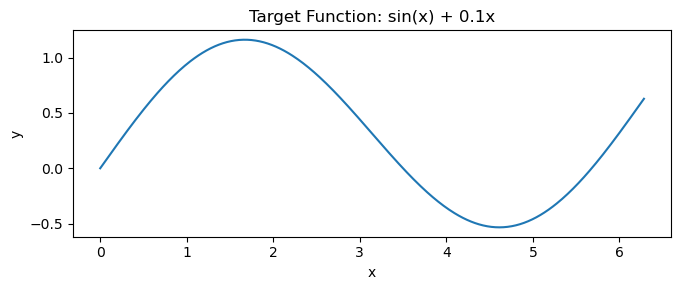

In [ ]:
def targetFunc(x):
    """Target function for curve fitting."""
    return np.sin(x) + 0.1 * x

x_plot = np.linspace(0.0, 2 * np.pi, 400)
plt.figure(figsize=(7, 3))
plt.plot(x_plot, targetFunc(x_plot))
plt.title('Target Function: sin(x) + 0.1x')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

## Dataset

在函数上采样生成数据集，然后使用 `train_test_split` 划分：Train / Val / Test。

- Train : 70%
- Val   : 10%
- Test  : 20%

In [10]:
# ==========================
# Dataset：采样 + 归一化 + 切分
# ==========================

# 1) 在原始区间 [0, 2π] 上均匀采样（一维输入）
#    X_raw: shape (N,)
X_raw = np.arange(0.0, 2 * np.pi, 0.002, dtype=np.float32)  # about 3142 points

# 2) 计算标签 y = f(x)
#    Y: shape (N,)
Y = targetFunc(X_raw).astype(np.float32)

# 3) 将输入归一化到 [-1, 1]：让手写 SGD + ReLU 更容易训练收敛
#    x_norm = (x - π) / π
#    X: shape (N,)
X = ((X_raw - np.pi) / np.pi).astype(np.float32)

# 4) 用 sklearn 切分 Train / Val / Test
#    注意：这里同时切分 X(归一化) 与 X_raw(原始) 来保证索引一致
#    - 训练时用 X（归一化后的输入）
#    - 画图/展示时用 X_raw（更直观）
X_train, X_test, y_train, y_test, X_train_raw, X_test_raw = train_test_split(
    X, Y, X_raw, test_size=0.2, random_state=1, shuffle=True
)
X_train, X_val, y_train, y_val, X_train_raw, X_val_raw = train_test_split(
    X_train, y_train, X_train_raw, test_size=0.125, random_state=1, shuffle=True
)

print(f"Training dataset: {X_train.shape}")
print(f"Validation dataset: {X_val.shape}")
print(f"Test dataset: {X_test.shape}")

Training dataset: (2198,)
Validation dataset: (315,)
Test dataset: (629,)


## Parameters initialization

两层网络（一个隐藏层 + 输出层）：

g(x) = W2 * ReLU(W1 * x + b1) + b2


In [11]:
# ==========================
# Parameters initialization：手写两层网络参数
# g(x) = W2 * ReLU(W1 * x + b1) + b2
# ==========================

input_dim = 1
hidden_dim = 64
output_dim = 1

# 权重初始化（非常关键）：
# - 第一层用 He 初始化（适配 ReLU，减轻梯度消失/爆炸）
# - 第二层用 Xavier/标准缩放初始化
# 形状约定：
# - W1: (H, 1)
# - b1: (H, 1)
# - W2: (1, H)
# - b2: (1, 1)
W1 = (np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim)).astype(np.float32)
W2 = (np.random.randn(output_dim, hidden_dim) * np.sqrt(1.0 / hidden_dim)).astype(np.float32)

b1 = np.zeros((hidden_dim, 1), dtype=np.float32)
b2 = np.zeros((output_dim, 1), dtype=np.float32)

# cache 用于保存 forward 中间结果，供 backward 使用
cache = {}

## Model (NumPy)

实现 `forward / loss_fn / backward`。

- 输入 batch：`(batch_size,)`
- 输出预测：`(batch_size,)`

In [12]:
def Linear(W, X, b):
    """线性层：Y = W @ X + b

    形状约定（B=batch_size, H=hidden_dim）：
    - W: (out, in)
    - X: (in, B)
    - b: (out, 1)
    - 返回: (out, B)
    """
    return (W @ X) + b


def relu(X):
    """ReLU 激活：max(0, x)（逐元素）"""
    return np.where(X > 0, X, 0.0).astype(np.float32)


def forward(x_batch):
    """前向传播（保存中间变量到 cache，供反向传播使用）

    参数：
    - x_batch: shape (B,)  —— 一批输入（已归一化到 [-1,1]）

    返回：
    - y_pred: shape (B,)  —— 一批预测值
    """
    # (B,) -> (1, B)
    x_batch = np.asarray(x_batch, dtype=np.float32).reshape(-1)
    X0 = x_batch.reshape(1, -1)
    cache['out0'] = X0

    # 第一层：Z1 = W1 X + b1, 形状 (H, B)
    Z1 = Linear(W1, X0, b1)
    cache['out1'] = Z1

    # 激活：A1 = ReLU(Z1), 形状 (H, B)
    A1 = relu(Z1)
    cache['out2'] = A1

    # 输出层：Z2 = W2 A1 + b2, 形状 (1, B)
    Z2 = Linear(W2, A1, b2)
    cache['out3'] = Z2

    # (1, B) -> (B,)
    return Z2.reshape(-1)


def loss_fn(y_pred, target):
    """均方误差（MSE）损失：mean((y_pred - y)^2)

    同时把 diff = (y_pred - y) 保存到 cache，反传会用到。
    """
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)
    target = np.asarray(target, dtype=np.float32).reshape(-1)

    diff = (y_pred - target).reshape(1, -1)  # (1, B)
    cache['diff'] = diff

    return float(np.mean(diff * diff))


def backward(lr, batch_size):
    """反向传播 + SGD 参数更新

    关键梯度（矩阵形式）：
    - dL/dZ2 = (2/B) * (y_pred - y)^T
    - dW2 = dZ2 @ A1^T
    - db2 = sum(dZ2)
    - dZ1 = (W2^T @ dZ2) * ReLU'(Z1)
    - dW1 = dZ1 @ X^T
    - db1 = sum(dZ1)
    """
    global W1, W2, b1, b2

    # dL/dZ2: (1, B)
    dZ2 = (2.0 / batch_size) * cache['diff']

    # 输出层梯度
    dW2 = dZ2 @ cache['out2'].T                 # (1, H)
    db2 = np.sum(dZ2, axis=1, keepdims=True)    # (1, 1)

    # 反传到隐藏层（注意 ReLU'）
    dA1 = (W2.T @ dZ2)                           # (H, B)
    dZ1 = dA1 * (cache['out1'] > 0).astype(np.float32)

    dW1 = dZ1 @ cache['out0'].T                  # (H, 1)
    db1 = np.sum(dZ1, axis=1, keepdims=True)     # (H, 1)

    # SGD 更新
    W1 -= lr * dW1
    W2 -= lr * dW2
    b1 -= lr * db1
    b2 -= lr * db2

## Training & Evaluation

使用 mini-batch 训练，并记录 Train/Val loss。

In [13]:
def predict(x_values):
    """推理/预测（向量化实现，不写 cache，避免影响训练 cache）

    输入：
    - x_values: shape (B,)

    输出：
    - y_pred: shape (B,)
    """
    x_values = np.asarray(x_values, dtype=np.float32).reshape(-1)

    # (B,) -> (1, B)
    X0 = x_values.reshape(1, -1)

    # forward (no cache)
    Z1 = (W1 @ X0) + b1
    A1 = np.where(Z1 > 0, Z1, 0.0).astype(np.float32)
    Z2 = (W2 @ A1) + b2

    return Z2.reshape(-1)


def mse(y_pred, y_true):
    """MSE 评估指标（标量）"""
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    return float(np.mean((y_pred - y_true) ** 2))


def train(X, y, X_val, y_val, epochs=4000, batch_size=64, lr=0.01, verbose_ep=400):
    """Mini-batch SGD 训练

    参数：
    - X, y: 训练集（shape (N,)）
    - X_val, y_val: 验证集（shape (N_val,)）
    - epochs: 训练轮数
    - batch_size: batch 大小
    - lr: 学习率
    - verbose_ep: 每隔多少 epoch 打印一次

    返回：
    - train_losses, val_losses: 记录每个 epoch 的 MSE
    """
    train_losses = []
    val_losses = []

    # 强制转成 float32 并拉平成一维，保证后面矩阵计算稳定
    X = np.asarray(X, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    X_val = np.asarray(X_val, dtype=np.float32).reshape(-1)
    y_val = np.asarray(y_val, dtype=np.float32).reshape(-1)

    n = len(X)
    for epoch in range(epochs):
        # 每个 epoch 打乱数据（SGD 常规做法）
        idx = np.random.permutation(n)
        X_shuf = X[idx]
        y_shuf = y[idx]

        rec_loss = 0.0
        steps = 0

        # 按 batch 切片训练
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            X_b = X_shuf[start:end]
            y_b = y_shuf[start:end]

            # forward -> loss -> backward update
            y_pred = forward(X_b)
            loss = loss_fn(y_pred, y_b)
            rec_loss += loss
            steps += 1

            backward(lr=lr, batch_size=(end - start))

        # epoch 级别的 train/val 指标
        train_mse = rec_loss / max(steps, 1)
        val_mse = mse(predict(X_val), y_val)

        train_losses.append(train_mse)
        val_losses.append(val_mse)

        if epoch % verbose_ep == 0:
            print(f"Epoch:{epoch}, Train MSE:{train_mse:.6f}, Val MSE:{val_mse:.6f}")

    return train_losses, val_losses


# 训练：这里的超参已调到“拟合效果好且稳定”的一组
train_losses, val_losses = train(
    X_train, y_train,
    X_val, y_val,
    epochs=6000,
    batch_size=128,
    lr=0.005,
    verbose_ep=600,
)

# 测试集评估
# Test MSE: 越小越好
# Test MAE: 绝对误差平均值，更直观
test_pred = predict(X_test)
test_mse = mse(test_pred, y_test)
test_mae = float(np.mean(np.abs(test_pred - y_test)))
print('Test MSE:', test_mse)
print('Test MAE:', test_mae)

Epoch:0, Train MSE:0.270116, Val MSE:0.210407
Epoch:600, Train MSE:0.003150, Val MSE:0.002737
Epoch:1200, Train MSE:0.000551, Val MSE:0.000470
Epoch:1800, Train MSE:0.000208, Val MSE:0.000183
Epoch:2400, Train MSE:0.000104, Val MSE:0.000097
Epoch:3000, Train MSE:0.000067, Val MSE:0.000063
Epoch:3600, Train MSE:0.000045, Val MSE:0.000045
Epoch:4200, Train MSE:0.000035, Val MSE:0.000035
Epoch:4800, Train MSE:0.000028, Val MSE:0.000029
Epoch:5400, Train MSE:0.000024, Val MSE:0.000026
Test MSE: 2.2936361347092316e-05
Test MAE: 0.0034208111464977264


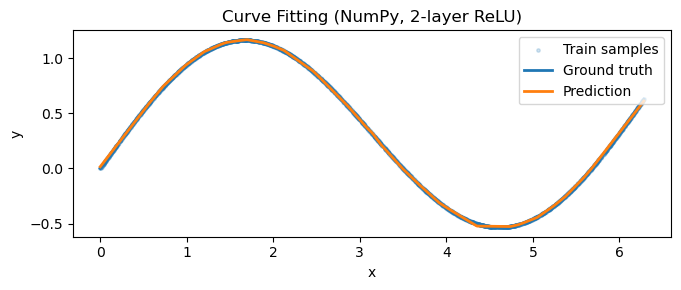

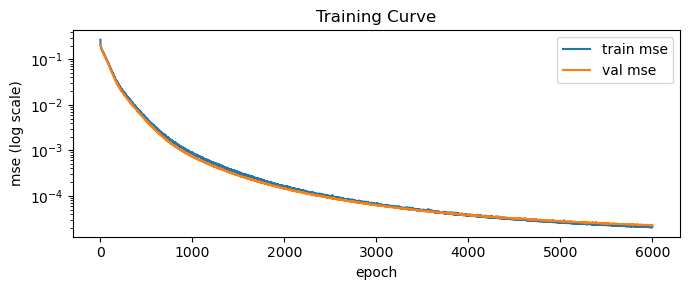

In [ ]:
# Fit curve visualization (plot against RAW x for readability)
x_line_raw = np.linspace(0.0, 2 * np.pi, 500, dtype=np.float32)
x_line = ((x_line_raw - np.pi) / np.pi).astype(np.float32)  # normalized

y_true_line = targetFunc(x_line_raw)
y_pred_line = predict(x_line)

plt.figure(figsize=(7, 3))
plt.scatter(X_train_raw, y_train, s=6, alpha=0.2, label='Train samples')
plt.plot(x_line_raw, y_true_line, linewidth=2, label='Ground truth')
plt.plot(x_line_raw, y_pred_line, linewidth=2, label='Prediction')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve Fitting (NumPy, 2-layer ReLU)')
plt.tight_layout()
plt.show()

# Training curve
plt.figure(figsize=(7, 3))
plt.plot(train_losses, label='train mse')
plt.plot(val_losses, label='val mse')
plt.yscale('log')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('mse (log scale)')
plt.title('Training Curve')
plt.tight_layout()
plt.show()